In [1]:
%load_ext autoreload
%autoreload 2
%env TORCH_COMPILE_DISABLE=1

env: TORCH_COMPILE_DISABLE=1


In [2]:
from brain_image.model.comm_alignment import CommAlignmentModel
from brain_image.model.prior import SimpleDiffusionPrior
from brain_image.utils import get_submodules_with_pattern
from brain_image.model.prior import DiffusionPriorConfig
from brain_image.data.data import get_from_batch

from pathlib import Path
import itertools as it
import numpy as np
from torch import Tensor
from torch.nn import functional as F
import tqdm
import pandas as pd
import torch

/home/gasparyanartur/dev/brain-image-implementation/.venv/lib/python3.12/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/home/gasparyanartur/dev/brain-image-implementation/.venv/lib/python3.12/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadat

In [3]:
comm_cp = Path("checkpoints/train_comm-15489137-20260208_000921/version_0/checkpoints/epoch_0030-val_loss_16.8979.ckpt")

comm = CommAlignmentModel.load_from_checkpoint(comm_cp)


INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42


In [4]:
#prior_cp = Path("checkpoints/train_eeg-15445445-20260206_025856/version_0/checkpoints/epoch_0484-val_loss_0.4309.ckpt")
prior_cp = Path("checkpoints/train_eeg-15489134-20260207_232707/version_0/checkpoints/last.ckpt")


state_dict = torch.load(prior_cp)
prior_config = state_dict["hyper_parameters"]["config"]["prior"]
prior_state_dict = get_submodules_with_pattern(state_dict["state_dict"], r"prior\.", get_full_name=False)
#for k in prior_state_dict.keys():
    #print(k)
prior = SimpleDiffusionPrior(
    DiffusionPriorConfig(**prior_config),
    embedding_stats=comm.data_module.get_embedding_stats()["align_img_latent"]
)
prior.load_state_dict(prior_state_dict)

<All keys matched successfully>

In [5]:
from brain_image.model.encoder.eeg_encoder.union import create_eeg_encoder

prior_eeg_encoder_cp = Path("checkpoints/train_eeg-15445398-20260206_014950/version_0/checkpoints/epoch_0164-val_loss_0.1633.ckpt")

prior_eeg_encoder = create_eeg_encoder(comm.config.eeg_encoder, checkpoint_path=prior_eeg_encoder_cp)

In [6]:
device = torch.device("cuda")
prior.eval()
prior.to(device)
comm.eval()
comm.to(device)
prior_eeg_encoder.eval()
prior_eeg_encoder.to(device)

example_batch = next(iter(comm.data_module.get_dataloader("test")))
example_batch.keys()

dict_keys(['img_path', 'eeg_data', 'idx', 'sub', 'align_img_latent'])

In [7]:

values = []

ns = list(np.linspace(0, 100, 20).astype(int))
gs = list(np.linspace(0, 4, 20))
params = list(it.product(ns, gs))

for n, g in tqdm.tqdm(params):
    with torch.no_grad():
        target = get_from_batch("align_img_latent", example_batch, Tensor).to(device)
        eeg = get_from_batch("eeg_data", example_batch, Tensor).to(device)
        eeg_latent = F.normalize(prior_eeg_encoder(eeg), dim=-1)
        clip_pred = prior.generate(conditioning=eeg_latent, guidance_scale=g, num_steps=n)
        mean_sim = round(F.cosine_similarity(target, clip_pred, dim=-1).mean().item(), 5)
        std_sim = round(F.cosine_similarity(target, clip_pred, dim=-1).std().item(), 5)
        
        values.append((n, g, mean_sim, std_sim))


df = pd.DataFrame(values, columns=["n", "g", "mean_sim", "std_sim"])
df = df.sort_values("mean_sim", ascending=False)
df

  0%|          | 0/400 [00:00<?, ?it/s]/home/gasparyanartur/dev/brain-image-implementation/.venv/lib/python3.12/site-packages/diffusers/schedulers/scheduling_ddpm.py:307: RuntimeWarning: divide by zero encountered in scalar floor_divide
  step_ratio = self.config.num_train_timesteps // self.num_inference_steps
100%|██████████| 400/400 [01:44<00:00,  3.82it/s]


,n,g,mean_sim,std_sim
27,5,1.473684,0.74976,0.07904
29,5,1.894737,0.74906,0.07682
25,5,1.052632,0.74898,0.07943
26,5,1.263158,0.74884,0.08190
28,5,1.684211,0.74858,0.07743
...,...,...,...,...
12,0,2.526316,0.49596,0.05586
14,0,2.947368,0.49576,0.05617
16,0,3.368421,0.49501,0.05618
19,0,4.000000,0.49476,0.05882


In [42]:
from typing import Literal


def get_faux_target(target, strength: float = 0.1, faux_type: Literal["noise", "drop"] = "noise"):
    n = target.size(0)
    device = target.device
    if faux_type == "noise":
        return torch.randn_like(target) * target.std(dim=0, keepdim=True) * strength + target
    elif faux_type == "drop":
        mask = torch.rand(n, device=device).unsqueeze(1) > strength
        return mask * target

In [36]:
prior

SimpleDiffusionPrior(
  (time_proj): Timesteps()
  (input_proj): LinearLayerNorm(
    (linear): Linear(in_features=768, out_features=1024, bias=True)
    (norm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
    (act_func): SiLU()
  )
  (time_encoders): ModuleList(
    (0): TimestepEmbedding(
      (linear_1): Linear(in_features=512, out_features=1024, bias=True)
      (act): SiLU()
      (linear_2): Linear(in_features=1024, out_features=1024, bias=True)
    )
    (1): TimestepEmbedding(
      (linear_1): Linear(in_features=512, out_features=512, bias=True)
      (act): SiLU()
      (linear_2): Linear(in_features=512, out_features=512, bias=True)
    )
    (2): TimestepEmbedding(
      (linear_1): Linear(in_features=512, out_features=256, bias=True)
      (act): SiLU()
      (linear_2): Linear(in_features=256, out_features=256, bias=True)
    )
    (3): TimestepEmbedding(
      (linear_1): Linear(in_features=512, out_features=128, bias=True)
      (act): SiLU()
      (linear_2

In [65]:
#torch.manual_seed(42)
from brain_image.metrics import get_retrieval_accuracy

with torch.no_grad():
    target = get_from_batch("align_img_latent", example_batch, Tensor).to(device)
    faux_target = get_faux_target(target, strength=4)
    eeg = get_from_batch("eeg_data", example_batch, Tensor).to(device)
    comm_eeg_latent = comm.eeg_encoder(eeg)
    prior_eeg_latent = prior_eeg_encoder(eeg)
    eeg_latent_normed = F.normalize(prior_eeg_latent, dim=-1)
    clip_pred = prior.generate(conditioning=eeg_latent_normed, guidance_scale=10.0, num_steps=100, unscale=True)

    z_proto_gt = comm.comm.encode_feature([comm_eeg_latent, target], [comm.config.eeg_idx, comm.config.img_idx], skip_encoder=True)
    z_proto_pred = comm.comm.encode_feature([comm_eeg_latent, clip_pred], [comm.config.eeg_idx, comm.config.img_idx], skip_encoder=True)
    z_img_target = comm.comm.encode_feature([target], comm.config.img_idx, skip_encoder=True)
    z_img_pred = comm.comm.encode_feature([clip_pred], comm.config.img_idx, skip_encoder=True)
    z_eeg = comm.comm.encode_feature([comm_eeg_latent], comm.config.eeg_idx, skip_encoder=True)


    z_proto_faux = comm.comm.encode_feature([comm_eeg_latent, faux_target], [comm.config.eeg_idx, comm.config.img_idx], skip_encoder=True)

    acc_proto_to_img, acc_img_to_proto = get_retrieval_accuracy(z_proto_pred, z_img_target, norm=True)
    acc_proto_to_img_target, acc_img_to_proto_target = get_retrieval_accuracy(z_proto_gt, z_img_target, norm=True)
    acc_proto_to_img_faux, acc_img_to_proto_faux = get_retrieval_accuracy(z_proto_faux, z_img_target, norm=True)
    acc_eeg_to_img, acc_img_to_eeg = get_retrieval_accuracy(comm_eeg_latent, target, norm=True)
    acc_clip_to_img, acc_img_to_clip = get_retrieval_accuracy(clip_pred, target, norm=True)
    acc_proto_eeg_to_target_img, _ = get_retrieval_accuracy(z_eeg, z_img_target, norm=True)
    
    print(f"Accuracy")

    print(f"\tz proto pred - z img: {acc_proto_to_img:0.4f}")
    print(f"\tz proto gt - z img: {acc_proto_to_img_target:0.4f}")
    print(f"\tz proto fake - z img: {acc_proto_to_img_faux:0.4f}")
    print(f"\tz eeg - z img: {acc_proto_eeg_to_target_img:0.4f}")

    print(f"\teeg - img target: {acc_eeg_to_img:0.4f}")
    print(f"\timg pred - img target: {acc_clip_to_img:0.4f}")

    print()
    print(f"Cosine Similarity:")
    print(f"\t z proto pred - z img - Target: {F.cosine_similarity(z_proto_pred, z_img_target, dim=-1).mean().item():0.4f}")
    print(f"\t z proto gt - z img: {F.cosine_similarity(z_proto_gt, z_img_target, dim=-1).mean().item():0.4f}")
    print(f"\t z proto fake - z img: {F.cosine_similarity(z_proto_faux, z_img_target, dim=-1).mean().item():0.4f}")
    print(f"\t z img pred - z img target: {F.cosine_similarity(z_img_pred, z_img_target, dim=-1).mean().item():0.4f}")
    print(f"\t target - clip pred: {F.cosine_similarity(target, clip_pred, dim=-1).mean().item():0.4f}")


Accuracy
	z proto pred - z img: 0.3300
	z proto gt - z img: 0.9800
	z proto fake - z img: 0.4000
	z eeg - z img: 0.1850
	eeg - img target: 0.6250
	img pred - img target: 0.4300

Cosine Similarity:
	 z proto pred - z img - Target: 0.3963
	 z proto gt - z img: 0.6903
	 z proto fake - z img: 0.3547
	 z img pred - z img target: 0.5545
	 target - clip pred: 0.7043


In [53]:
C = 32
z1_proto_pred, z2_proto_pred, *_ = torch.chunk(z_proto_pred, C)
z1_img_target, z2_img_target, *_ = torch.chunk(z_img_target, C)
z1_proto_faux, z2_proto_faux, *_ = torch.chunk(z_proto_faux, C)

print(F.cosine_similarity(z1_proto_faux, z1_img_target).detach().cpu(), "Faux proto (5std), Real target")
print(F.cosine_similarity(z1_proto_pred, z1_img_target).detach().cpu(), "Pred proto, Real target")
print(F.cosine_similarity(z1_img_target, z2_img_target).detach().cpu(), "Wrong target, Real target")

tensor([0.3851, 0.3022, 0.4334, 0.3348, 0.3593, 0.4964, 0.4000]) Faux proto (5std), Real target
tensor([0.4548, 0.5242, 0.6270, 0.4089, 0.4517, 0.5398, 0.4420]) Pred proto, Real target
tensor([0.0918, 0.1630, 0.2777, 0.2352, 0.1353, 0.2742, 0.4900]) Wrong target, Real target


In [54]:
print(clip_pred[:5:, :5].detach().cpu(), "Predicted img embedding [:5, :5]")
print(target[:5, :5].detach().cpu(), "Target img embedding [:5, :5]")

tensor([[ 0.3140, -0.0289, -0.5880, -0.2871, -0.2623],
        [ 0.3140, -0.0422,  0.1933, -0.8506,  0.2186],
        [ 0.3140,  0.7516, -0.5023, -0.1658, -0.2289],
        [ 0.3035,  0.5397,  0.1933, -0.6599,  0.2488],
        [ 0.3140,  0.6386, -0.2310, -0.5897,  0.1114]]) Predicted img embedding [:5, :5]
tensor([[ 0.0828,  0.5718,  0.2036, -0.3485, -0.0911],
        [ 0.4780, -0.3975,  0.1124, -0.7704, -0.1343],
        [ 0.1215,  1.3899, -1.0008, -0.8444, -0.0954],
        [ 0.1026,  0.1777, -0.0129, -0.3795, -0.0580],
        [ 0.0089,  0.1848, -0.4509, -0.8934, -0.0066]]) Target img embedding [:5, :5]


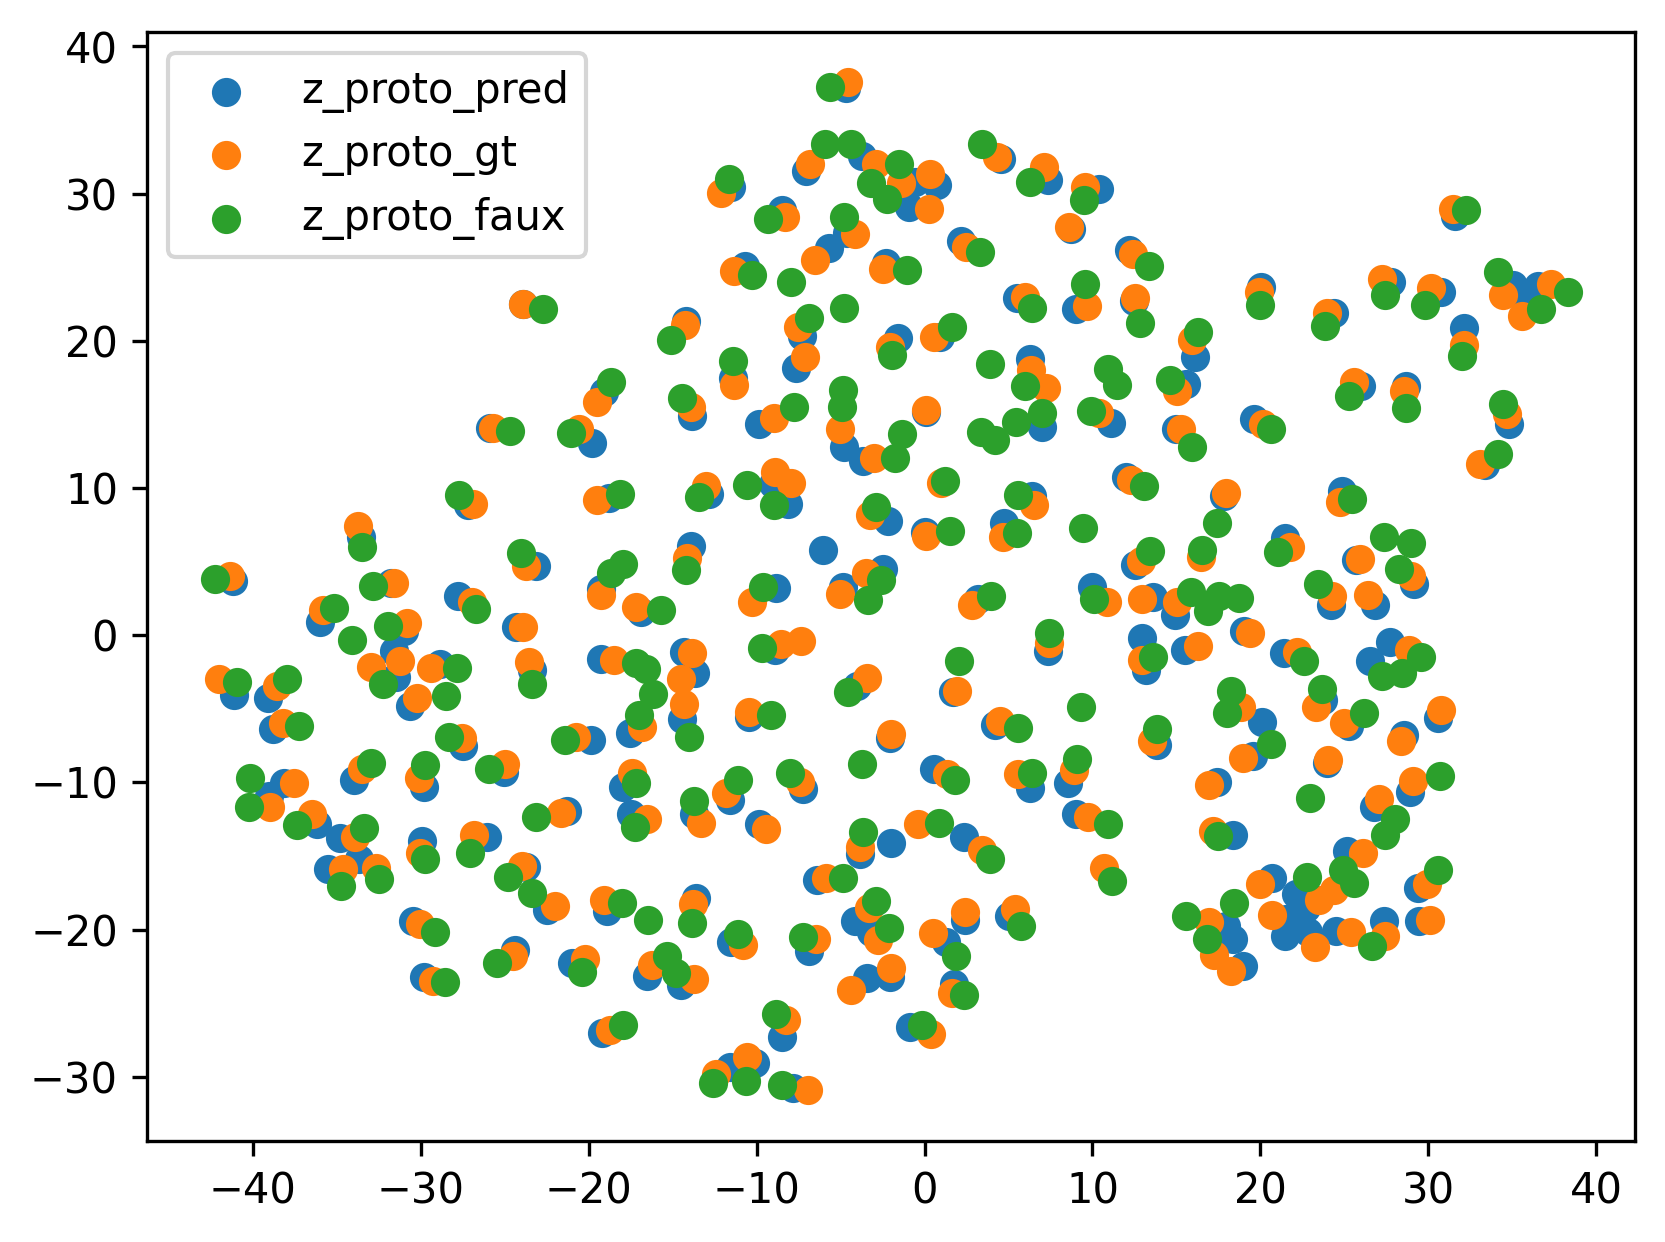

In [66]:
from brain_image.stats import plot_projected_latents

#plot_projected_latents([clip_pred, target, faux_target], ["clip_pred", "target", r"target+$5\sigma$"])
plot_projected_latents([z_proto_pred, z_proto_gt, z_proto_faux], ["z_proto_pred", "z_proto_gt", "z_proto_faux"])

In [86]:
# Important dimensions

from torch import pca_lowrank

U, S, Vh = pca_lowrank(target, q=100, center=True, niter=5)
print(S, len(S))

print(Vh.shape)

explained_variance = Vh.cumsum(1) / Vh.sum()
print(explained_variance[0])

tensor([48.7136, 46.3122, 35.8157, 30.8014, 28.7028, 25.7184, 23.3673, 21.4505,
        20.7176, 20.0486, 18.5208, 17.1476, 16.7373, 16.1592, 15.4213, 14.8743,
        14.6403, 14.1214, 13.7509, 13.3851, 12.5628, 12.2879, 11.9417, 11.7420,
        11.5226, 11.2390, 11.0233, 10.9505, 10.7194, 10.6947, 10.2498, 10.0156,
         9.8653,  9.7265,  9.4935,  9.4093,  9.2182,  8.8318,  8.7095,  8.6839,
         8.5294,  8.5112,  8.4301,  8.3918,  8.2424,  8.1211,  7.9835,  7.8342,
         7.7731,  7.6588,  7.4500,  7.3892,  7.3168,  7.2866,  7.1871,  7.1273,
         6.9974,  6.9024,  6.8019,  6.7073,  6.6386,  6.5064,  6.4308,  6.3717,
         6.3094,  6.2767,  6.2431,  6.1284,  6.0859,  6.0484,  5.9747,  5.9453,
         5.9138,  5.8382,  5.7754,  5.7394,  5.6667,  5.5886,  5.5440,  5.4632,
         5.4259,  5.4116,  5.3577,  5.2631,  5.1973,  5.1607,  5.1109,  5.0578,
         5.0210,  4.9768,  4.8975,  4.8608,  4.7925,  4.7540,  4.6011,  4.5871,
         4.5444,  4.4819,  4.4525,  4.27